# Summary Notebook

In [2]:
import pandas as pd
from IPython.display import Image

In Sprint 1, we use Domain API to scrape recent rental properties in Victoria. 

In Sprint 2, we gathered all the necessary rental property and external datasets. 

The rental property data was read from a JSON file, and we selected essential features related to the property details, including location (suburb, postcode, latitude, longitude), attributes (bedrooms, bathrooms, car spaces), and pricing information.
We preprocessed the raw data into a more analyzable form by:

· Retaining the critical features from the original dataset.

· Converting the price column into a standardized weekly price using regular expressions to handle various formats (e.g., per week).

· Cleaning the data by filtering out rows with missing latitude, longitude, or price values.

· Further filtering out unreasonable pricing values by setting a threshold of 200 or more per week.

This prepared dataset will serve as the foundation for further analysis and modeling tasks.

We utilized Statistical Areas Level 2 (SA2) to derive population forecasts and analyze affluence.

For population forecasting, we calculated the overall average growth rate by using pct_change for each year and predicted growth for the next three years (2024-2026). The growth rates were then visualized with Folium, using the SA2 area Shapefile. The top five regions with the highest predicted growth rates are: `Clyde North - South`, `Point Cook - South`, `Cranbourne North - East`, `Clyde North - North`, and `Doreen - South`.

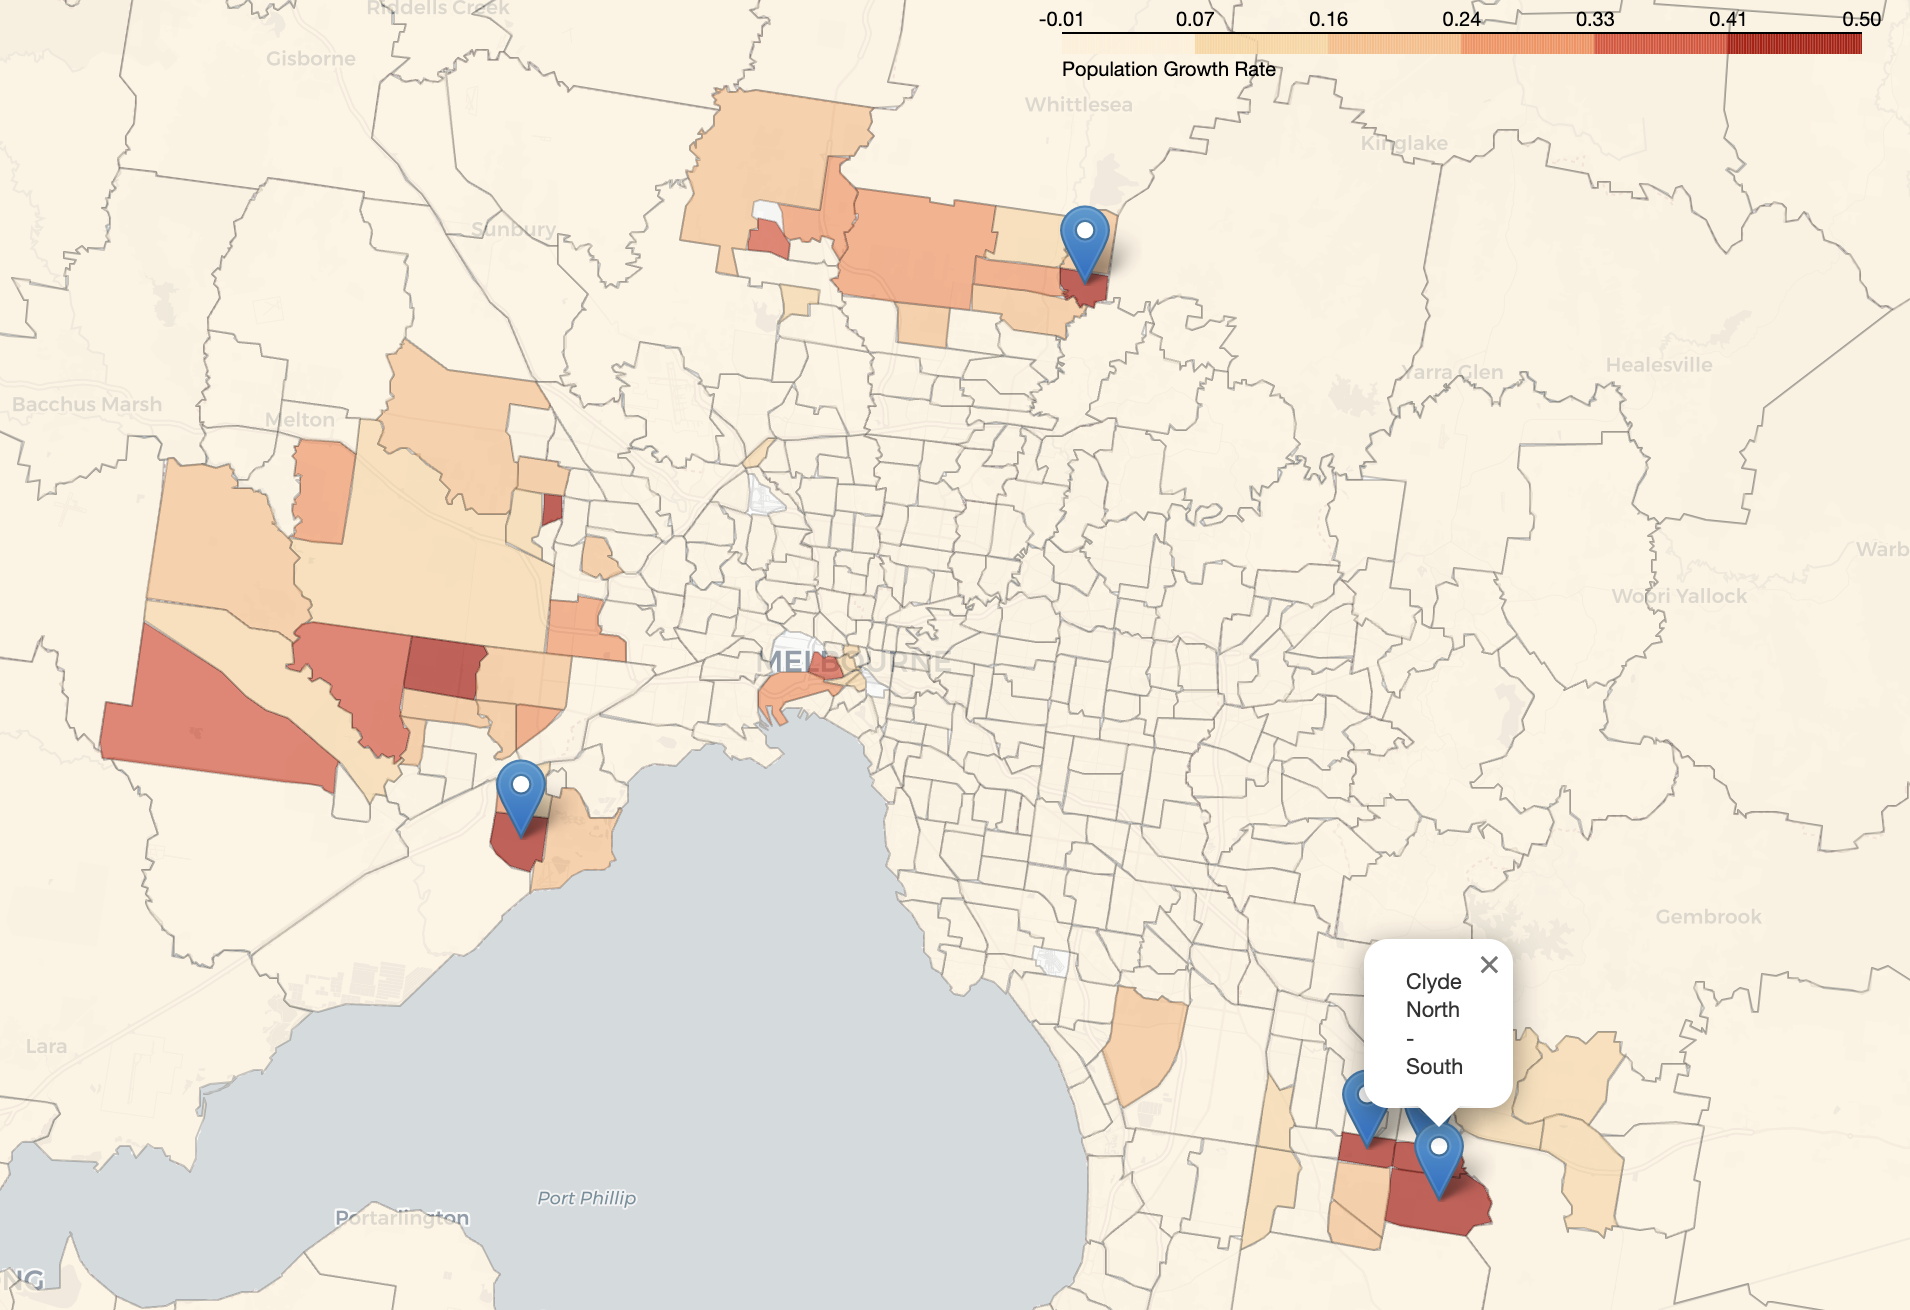

In [7]:
Image(filename='../plots/population_forecast.png',width=800, height=400)

Then, we used Statistical Areas Level 2 (SA2) to derive affluence based on income data from 2016 to 2021. The affluence index we defined is a weighted combination of 70% average income and 30% population growth rate. The results were visualized using an SA2 shapefile. 

The top five SA2 areas with the highest affluence index are: `Port Melbourne`, `East Melbourne`, `West Melbourne - Industrial`, `Richmond (South) - Cremorne`, and `Toorak`, primarily located around the central areas.


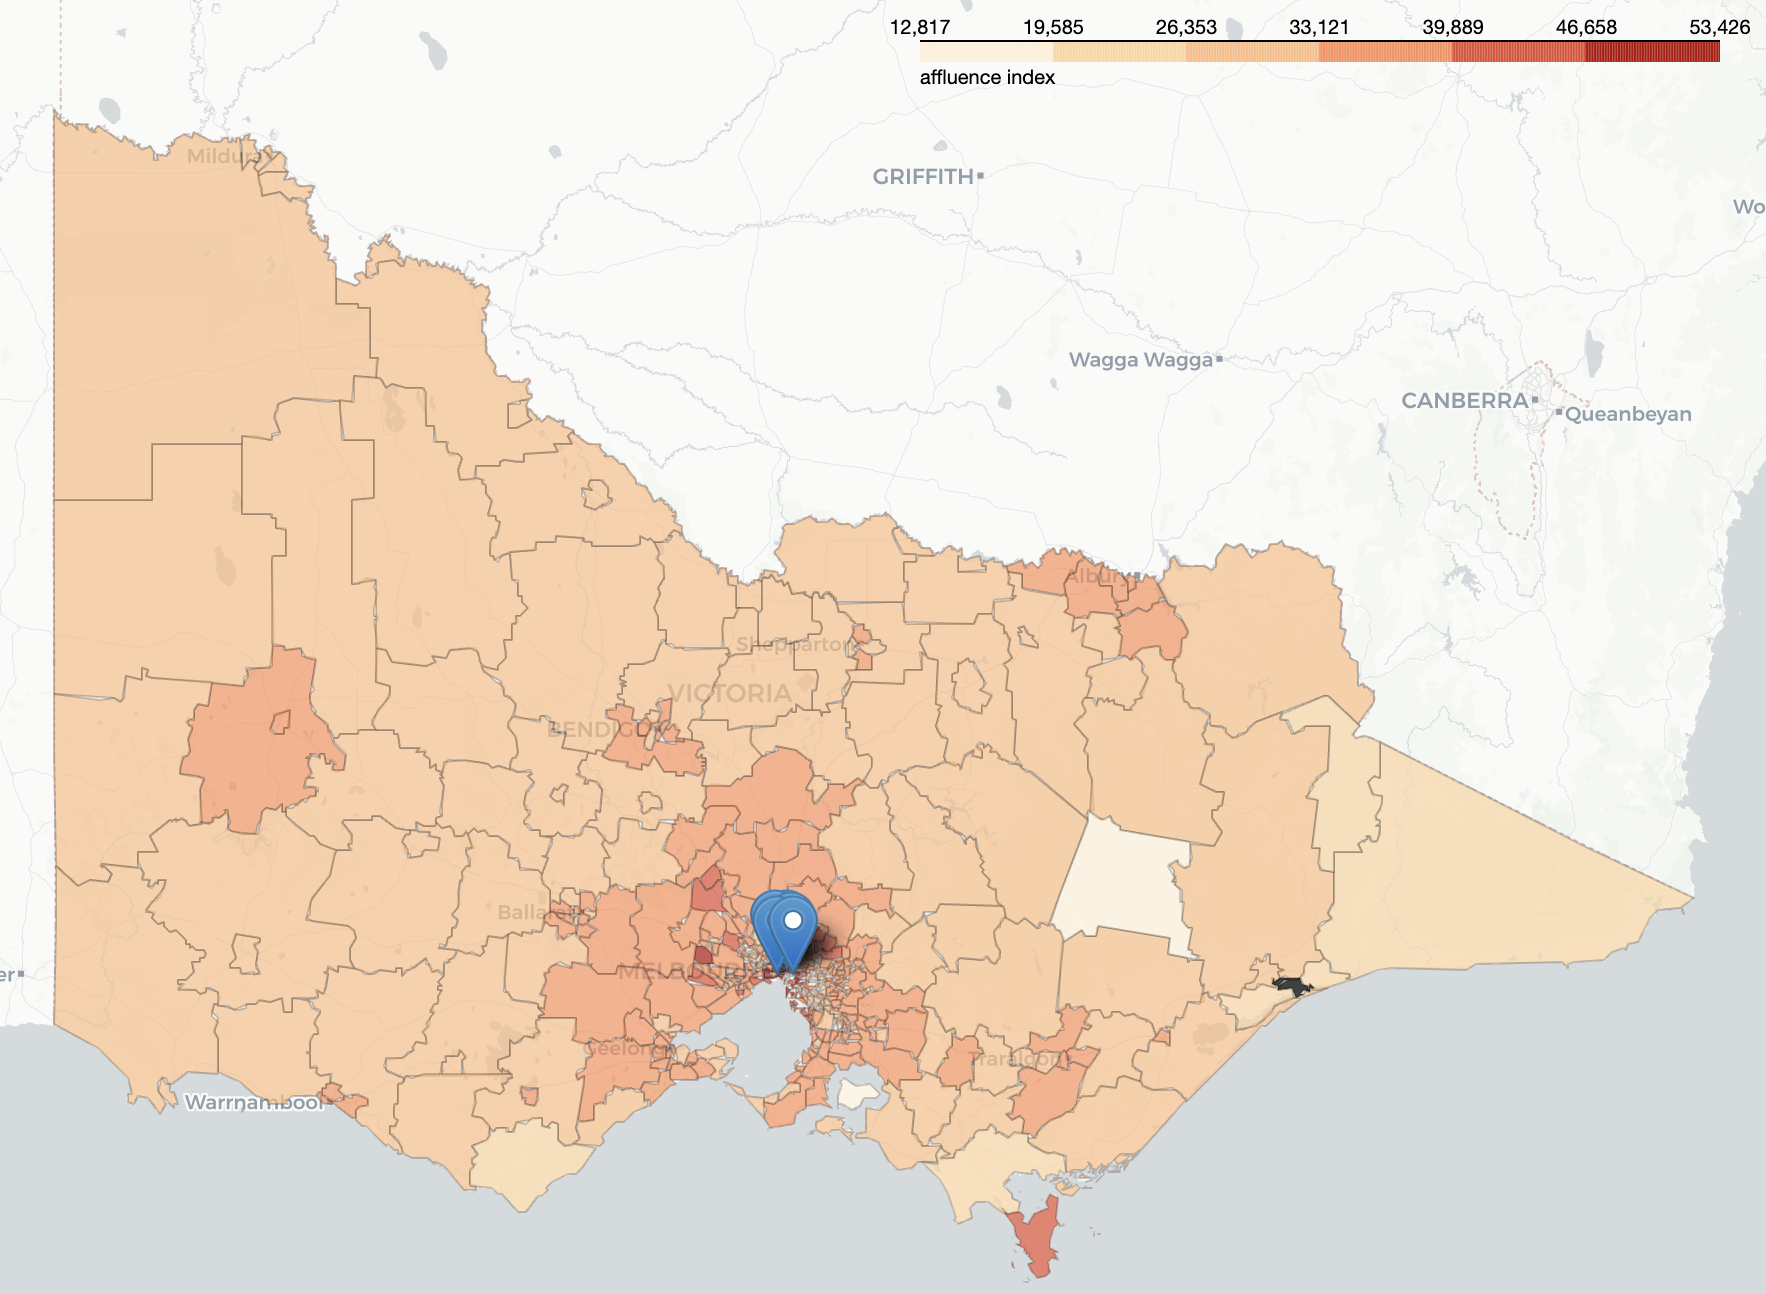

In [8]:
Image(filename='../plots/affluence_index.png',width=800, height=400)

In Sprint 3, we began working with the OpenStreetMap API to calculate the proximity to key locations, including the nearest train station, school, and Melbourne CBD. In the end we wnat to **find the connection between key locations and rent price**. (Does apartments that are close to train station have higher rent? eg.)


For each unique property in the rental property dataset, we derived its travel distance and travel time to the nearest school/train station as well as Melbourne CBD. The OPEN ROUTE SERVICE API was used to find the optimal route by car and the extected travel time/distance. 
However, due to the limited API token available to student account, we had to limit number of API calls for each unique property. To achieve that, we found the tree most nearest key locations to the property (top 3 nearest school & top 3 nearest train station) by linear distance on map, then we used the OPEN ROUTE SERVICE API to find the nearest key location. 

In the end, we had the following finding: 


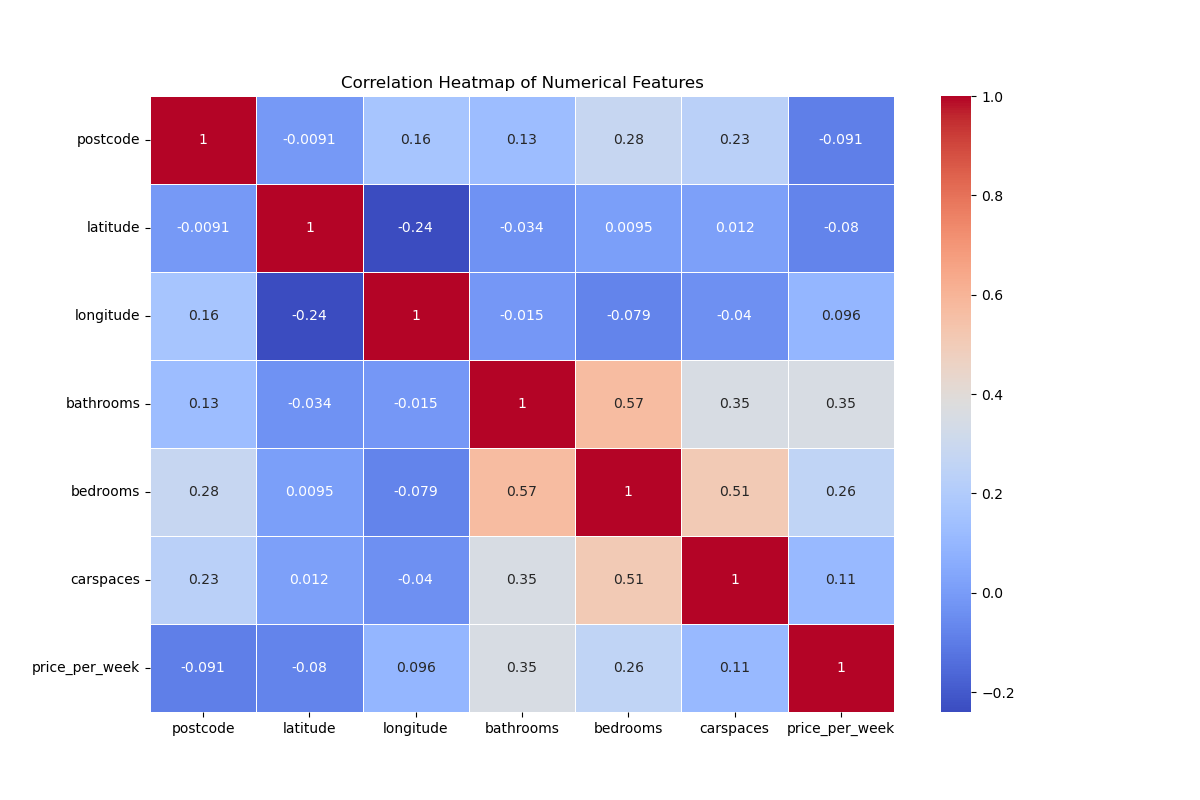

In [4]:
Image(filename='../plots/correlation_heatmap.png',width=800, height=400)

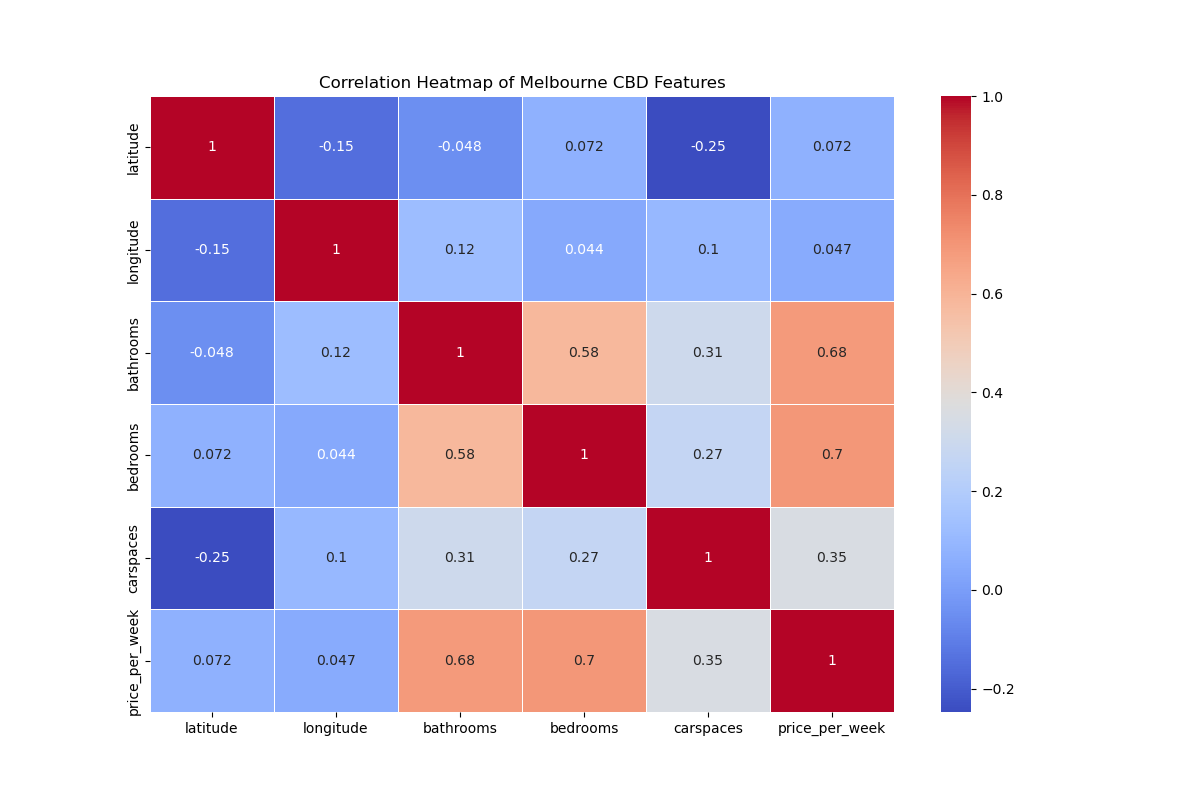

In [5]:
Image(filename='../plots/correlation_heatmap_of_melbCBD.png',width=800, height=400)

As postcode 3000 (Melbourne CBD) accounted for 7.43% of the total data, we compared the overall dataset with data filtered specifically for Melbourne CBD.

In the Melbourne CBD heatmap, the correlations between features and rental prices generally became stronger compared to the overall dataset. For example, bedrooms, bathrooms, and car spaces showed a much higher correlation with rental prices. This may be due to the higher demand for space and amenities in the city center, where properties are more valuable, and parking is scarce.

This comparison helps to highlight the unique dynamics of the Melbourne CBD rental market in contrast to the broader dataset.

**External Features Analysis**

Train Station, School and CBD's influence on rent price

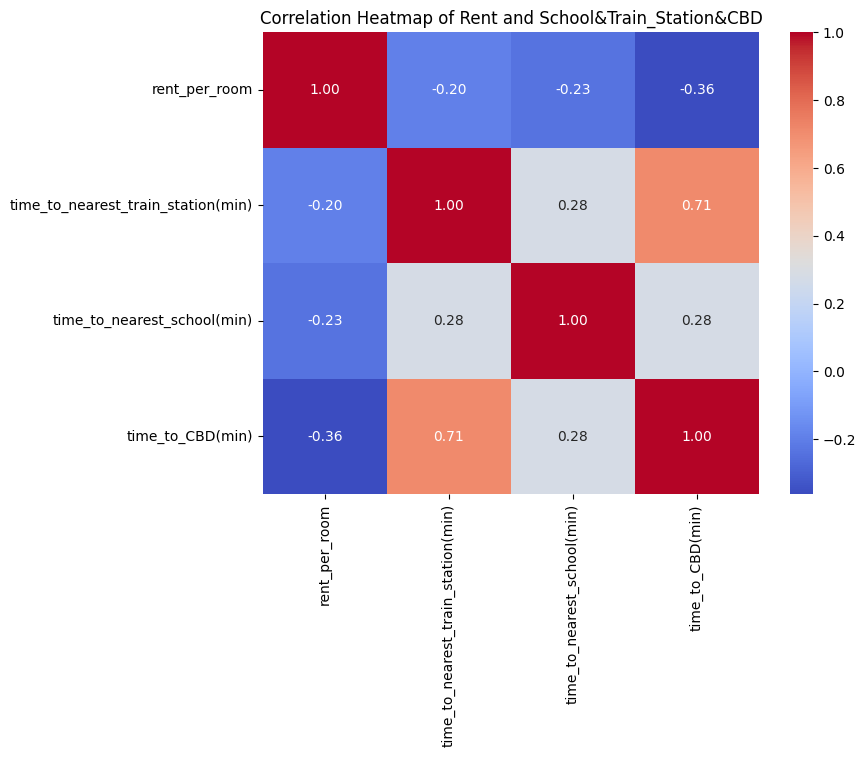

In [11]:
Image(filename='../plots/rent_school_train_CBD_heatmap.png')

The correlation analysis shows that the most significant factor that influence rent price is the distance to the CBD, with a moderate negative correlation of -0.36. This indicates that properties closer to the CBD tend to have higher rental prices. The distance to the nearest train station and school also negatively correlates with rent (-0.20 and -0.23, respectively), but the effect is weaker compared to the CBD. This suggests that while being closer to train stations and schools slightly increases rental prices, proximity to the CBD is the strongest external factor driving rental prices in the regions analyzed.


income and population's influence on rent price

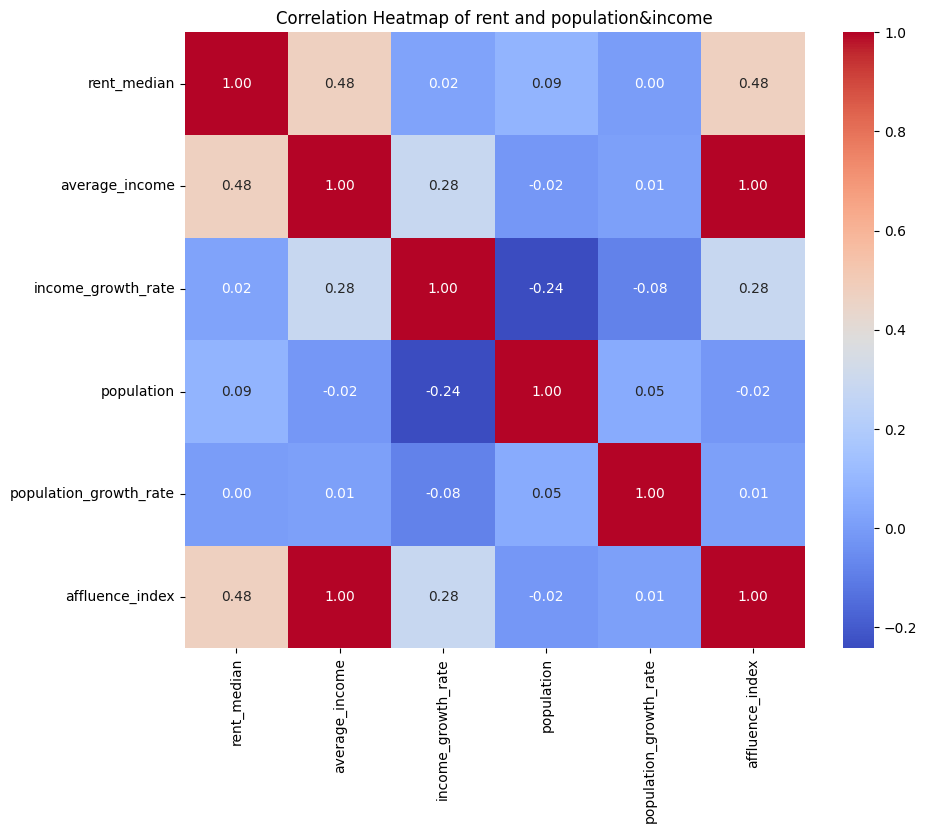

In [10]:
Image(filename='../plots/rent_population_income_heatmap.png')

The correlation analysis reveals that average income is the most important factor influencing rental prices, with a moderate positive correlation of 0.48. This suggests that regions with higher average incomes tend to have higher rental prices. While the affluence index also shows a positive correlation with rent, its significance mainly stems from its inclusion of income, as population itself has a very weak correlation with rental prices. The population’s contribution to the affluence index is negligible, indicating that demographic factors like population size and growth rate have an insignificant impact on rental prices compared to income. Thus, income alone is the primary driver of rental prices among the variables analyzed.

### Question 3:liveable and affordable

Q3: What are the most liveable and affordable suburbs according to your chosen metrics?

liveable suburb: Livable suburb provide enough amenities to make life easier, as well as lower financial stress for residents.

affordable suburb: affordable suburb to focus on the income of the residents and the rent of the housing stock, much times yearly income to yearly rent means more affordable.

For analysis liveability:

1.calculate the count of infrastructures(school and train station) nearby each suburb and statistics on the sum of populations and the average value of rents in different regions.

2.Assign different weights to school counts, train counts, population, and rent to calculate the viability index for each school.

3.draw a map, add layers, add markers and add heat map of population.

In [7]:
liveable_index = pd.read_csv("../data/curated/liveability_index")

In [8]:
liveable_index.iloc[:10,:]

,Unnamed: 0,Address_Postcode,school_count,postcode,train_count,2023,price_per_week,liveability_index
0,291,3352.0,0.444444,3352,1.000000,0.601994,0.154067,0.463068
1,610,3825.0,0.444444,3825,0.491803,0.858425,0.019737,0.402194
2,289,3350.0,1.000000,3350,0.360656,0.540677,0.114079,0.382109
3,508,3691.0,0.259259,3691,0.590164,1.000000,0.261404,0.350480
4,638,3875.0,0.370370,3875,0.557377,0.450241,0.164286,0.282050
5,413,3551.0,0.370370,3551,0.655738,0.313194,0.176316,0.280539
6,412,3550.0,0.740741,3550,0.245902,0.444751,0.185938,0.255088
7,708,3977.0,0.962963,3977,0.180328,0.296214,0.193026,0.248026
8,307,3377.0,0.259259,3377,0.409836,0.401253,0.112281,0.221369
9,360,3461.0,0.111111,3461,0.442623,0.540008,0.181579,0.208537


For analysis affordability:

1.calculate affordable index by 
affordable index = $$ \dfrac{yearly income}{yearly rent} $$

2.Render the affordable index as a base colour on the base map, the darker the colour the larger the affordable index, the more affordable the suburb is.



In [5]:
affordable_index = pd.read_csv('../data/curated/rent_income_2023-24.csv')
affordable_index = affordable_index.sort_values(by='affordable index of 2023-24',ascending=False)

In [6]:
affordable_index.iloc[:10,:]

,Unnamed: 0,postcode,SA2,suburb,latitude,longitude,median income of 2023-24,median rent per week of 2023-24,affordable index of 2023-24
621,621,3212,203021043,Lara,-38.013475,144.401553,60759.903158,10400.0,5.842298
2680,2680,3981,212011548,Koo Wee Rup,-38.181543,145.469598,60515.983555,10400.0,5.818845
1324,1324,3000,206041119,Melbourne,-37.812024,144.969996,88862.163133,16120.0,5.512541
988,988,3058,206011497,Coburg North,-37.721361,144.958501,62347.983754,11440.0,5.449999
994,994,3058,210031236,Coburg North,-37.721361,144.958501,62347.983754,11440.0,5.449999
2260,2260,3081,209011199,Heidelberg Heights,-37.732063,145.060126,62008.956946,11440.0,5.420363
1678,1678,3181,206061136,Windsor,-37.853356,144.992530,81175.176456,15080.0,5.382969
782,782,3690,204031492,Wodonga,-36.128816,146.863823,55626.836071,10400.0,5.348734
1670,1670,3181,206061136,Prahran,-37.848507,144.990328,81175.176456,15990.0,5.076621
3955,3955,3396,215011394,Hopetoun,-35.733631,142.366467,52549.283369,10400.0,5.052816


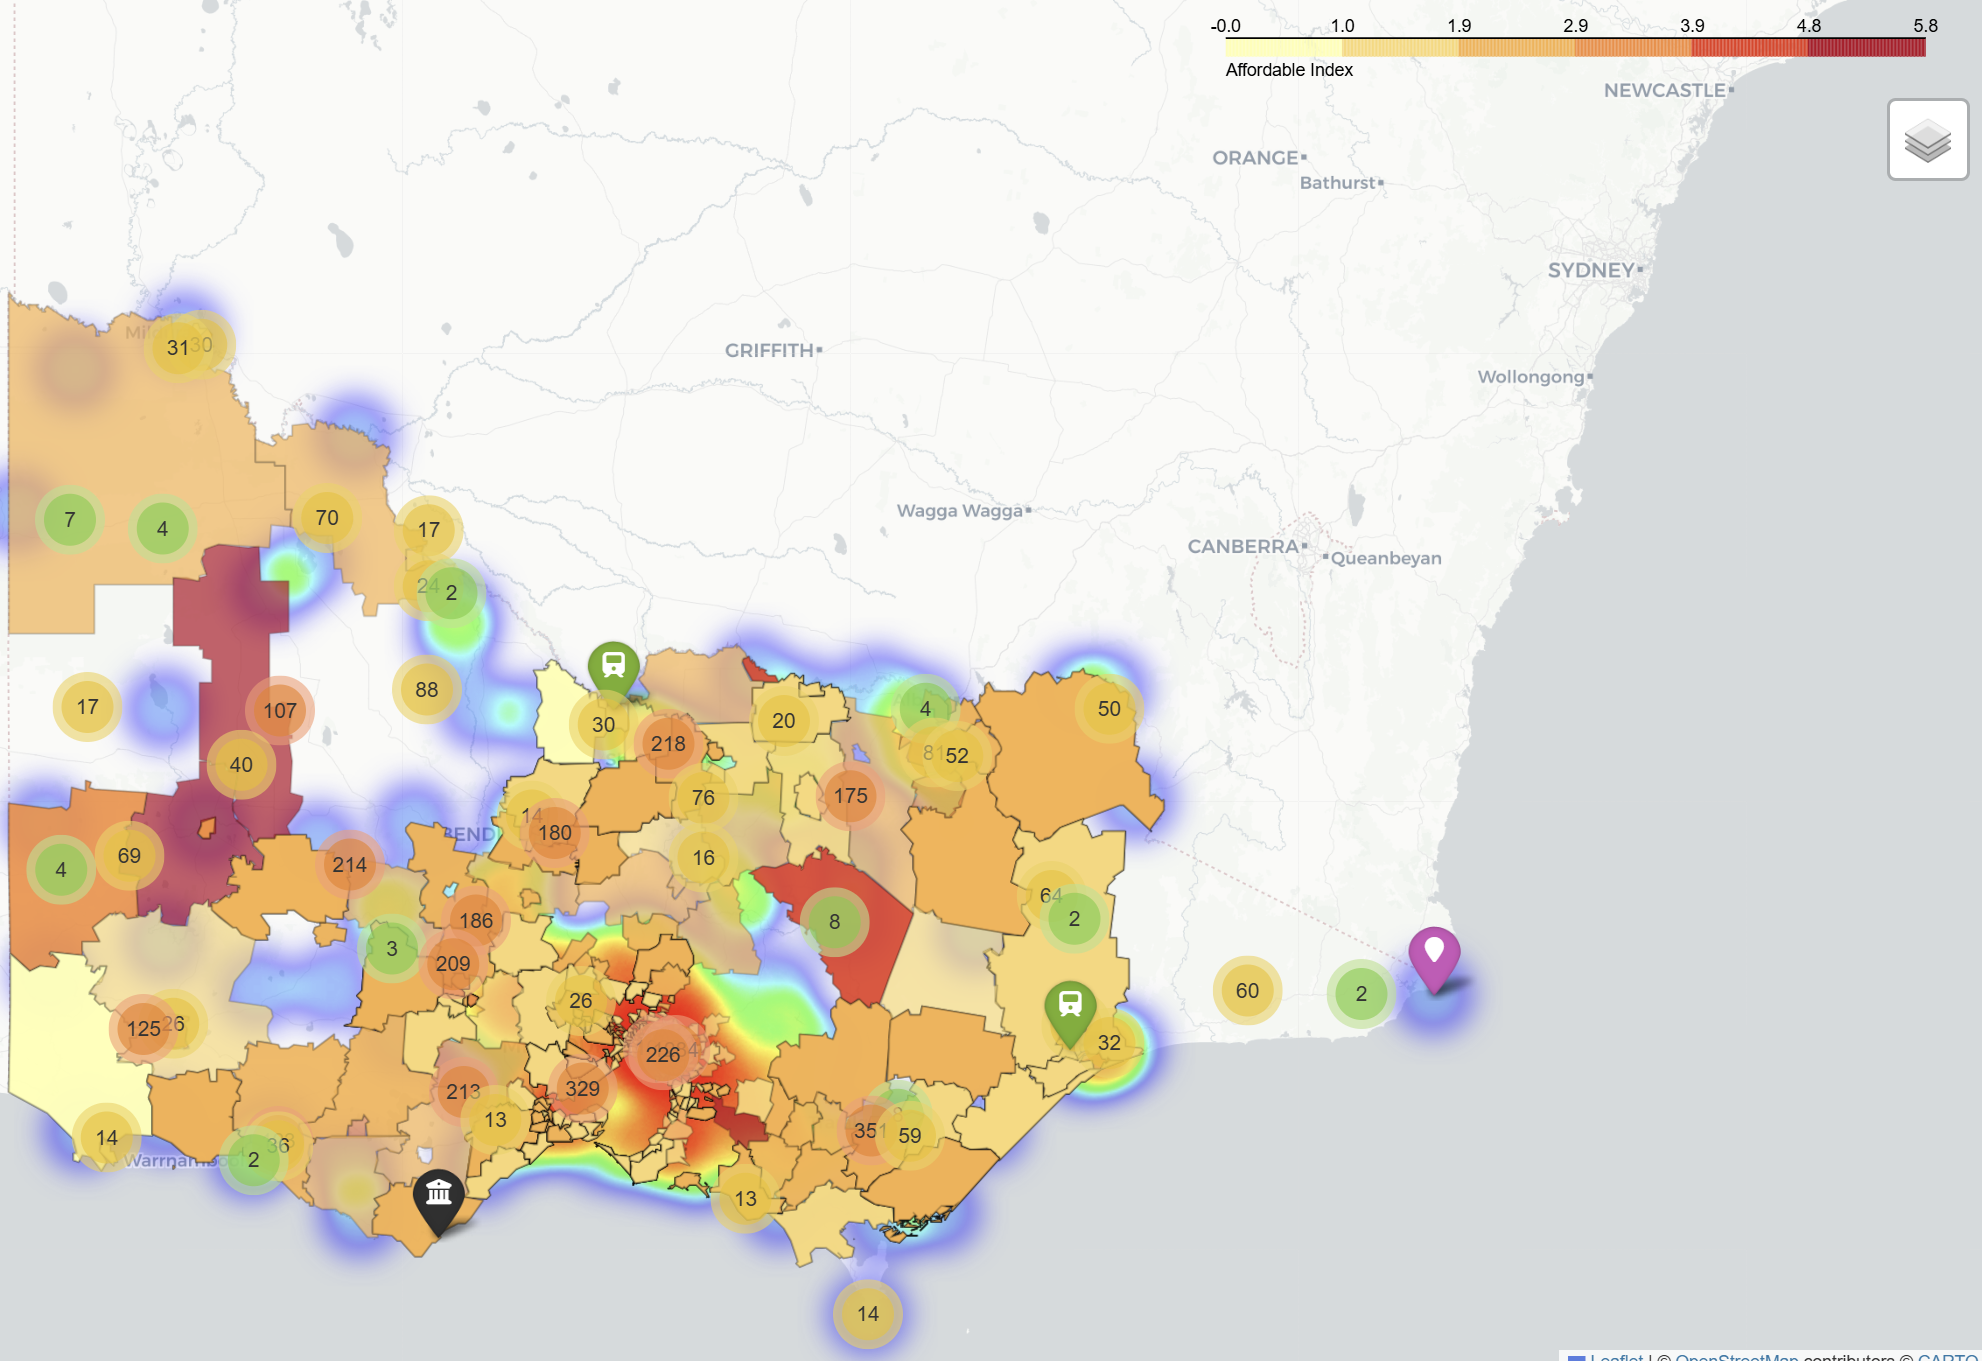

In [4]:
Image(filename='../plots/liveable.png')

In [9]:
all_index = pd.read_csv('../data/curated/index.csv')
all_index.iloc[:10,:]

,Unnamed: 0,postcode,index
0,712,3981,0.839035
1,610,3825,0.789927
2,327,3409,0.736872
3,321,3396,0.723167
4,289,3350,0.595850
5,530,3722,0.593363
6,507,3690,0.588638
7,267,3318,0.580545
8,291,3352,0.563594
9,549,3747,0.553795


The affordable index and liveable index were taken in the ratio of 3:7 to get the total index, from which it was concluded that 3981 was the most liveable and affordable suburb. from the image it can also be seen that 3981 has the darkest base colour (the most affordable) and the peripheral markers are also very high (there are many daily amenities in the neighbourhood, which enhances the livability of the area very well). 

So we conclude that 3981 is the most liveable and affordable suburb in Victoria State.

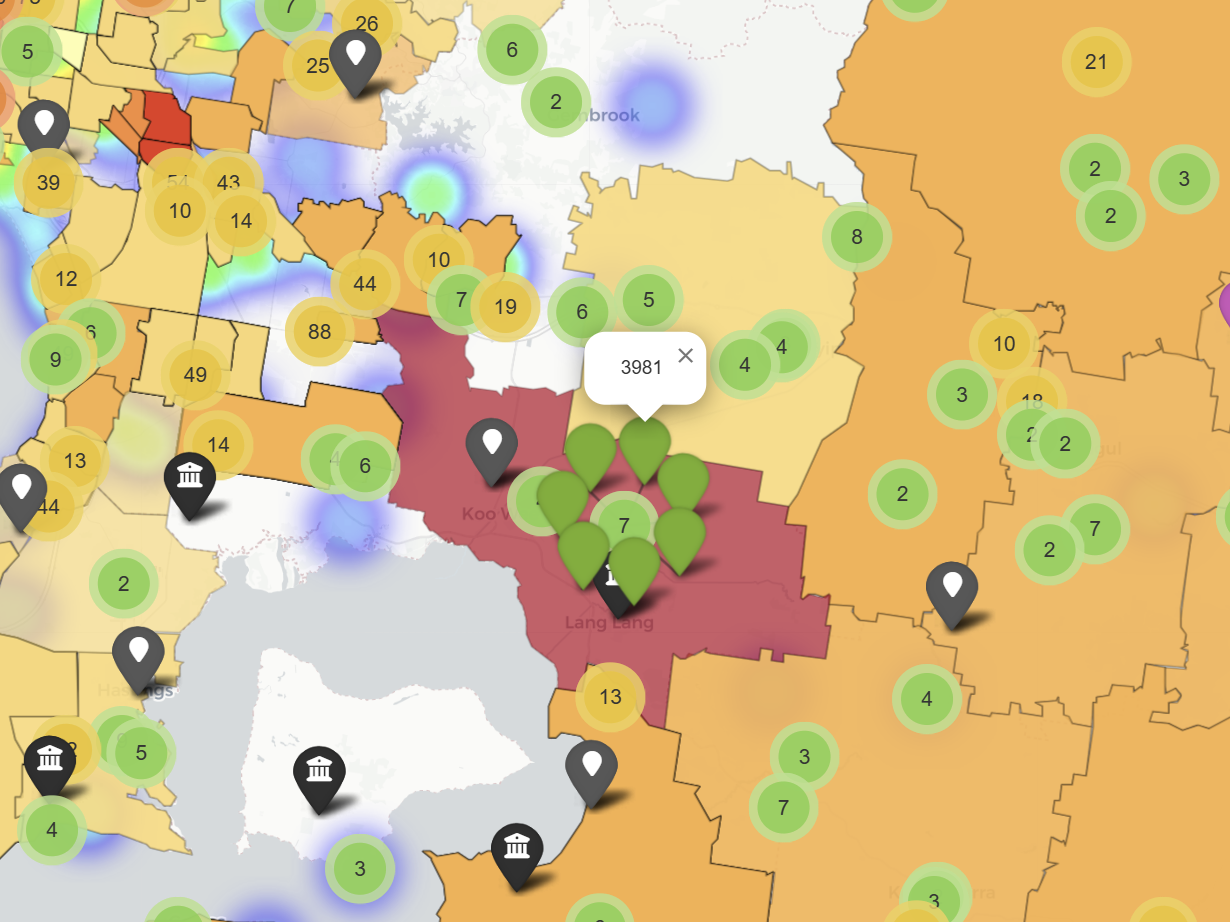

In [12]:
Image(filename='../plots/liveable_3981.png')

<h3>Model</h3>

For data preprocessing of model prediction, we used "postcode" groupby to get a new 2023 rent datasets and combined it with 2000-2022 rent datasets. We used data from 2000-2023 to predict population and income for the next 2024-2028. Population is predicted directly using population growth rate, and income is predicted using ARIMA model.

In [6]:
df_pred = pd.read_csv("../data/curated/dataset_pred.csv")
df_pred.head(3)

,Unnamed: 0,postcode,income,population,year
0,0,3004.0,92221.691292,5175.824488,2024
1,1,3004.0,72623.064667,6867.332701,2024
2,2,3004.0,80750.167943,17103.056186,2024


In [5]:
rent_df = pd.read_csv("../data/curated/model_rent_df.csv")
rent_df.head(3)

,Unnamed: 0,suburb,postcode,2016_rent_median,2017_rent_median,2018_rent_median,2019_rent_median,2020_rent_median,2021_rent_median,2022_rent_median,2023.5_rent_median
0,0,Albert Park-Middle Park-West St Kilda,3004.0,515.0,527.75,562.5,568.0,570.0,498.75,510.0,521.503759
1,1,Albert Park-Middle Park-West St Kilda,3004.0,515.0,527.75,562.5,568.0,570.0,498.75,510.0,521.503759
2,2,Albert Park-Middle Park-West St Kilda,3004.0,515.0,527.75,562.5,568.0,570.0,498.75,510.0,521.503759


The Linear Regression Model and Random Forest Model were used to predict each suburb yearly rent median of next 5 years. The model logic was to use historical data for training, and then use the income and population of the current year as input features.

For the Linear Regression model.

In [8]:
# top 10 suburbs with the highest growth rate
top_10_LR = pd.read_csv("../data/curated/top10_LR.csv")
top_10_LR

,Unnamed: 0,suburb,postcode,max_growth_rate
0,51,Hawthorn,3122.0,12.721404
1,27,West Brunswick,3055.0,7.631956
2,82,Prahran-Windsor,3181.0,7.530206
3,40,Fairfield-Alphington,3078.0,7.211755
4,85,Elwood,3184.0,6.651157
5,29,East Brunswick,3057.0,6.403853
6,30,Broadmeadows-Roxburgh Park,3064.0,6.321335
7,36,Thornbury,3071.0,6.147849
8,14,Flemington-Kensington,3031.0,6.007226
9,64,Malvern East,3145.0,5.995516


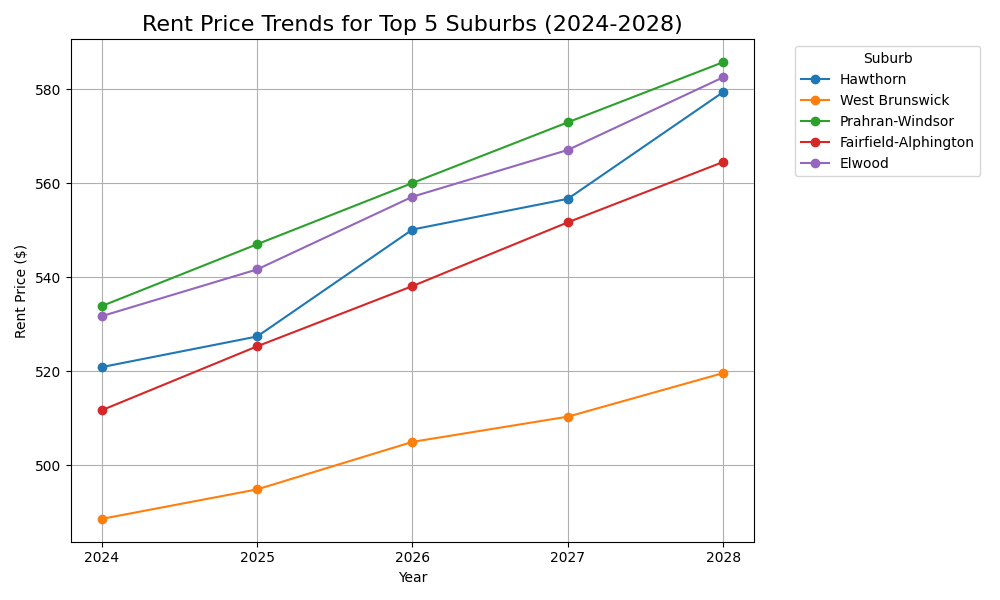

In [11]:
Image(filename="../plots/top5_LR_plot.png")

For the Random Forest Model.

In [12]:
# top 10 suburbs with the highest growth rate
top_10_RF = pd.read_csv("../data/curated/top10_RF.csv")
top_10_RF

,Unnamed: 0,suburb,postcode,max_growth_rate
0,51,Hawthorn,3122.0,7.710585
1,136,Moe-Newborough,3825.0,5.797835
2,40,Fairfield-Alphington,3078.0,4.574923
3,125,Swan Hill,3585.0,4.185780
4,115,Horsham,3400.0,4.133101
5,135,Warragul,3820.0,3.907573
6,79,Dandenong,3175.0,3.840602
7,27,West Brunswick,3055.0,3.832279
8,112,Mount Clear-Buninyong,3350.0,3.592955
9,111,Ballarat,3350.0,3.514156


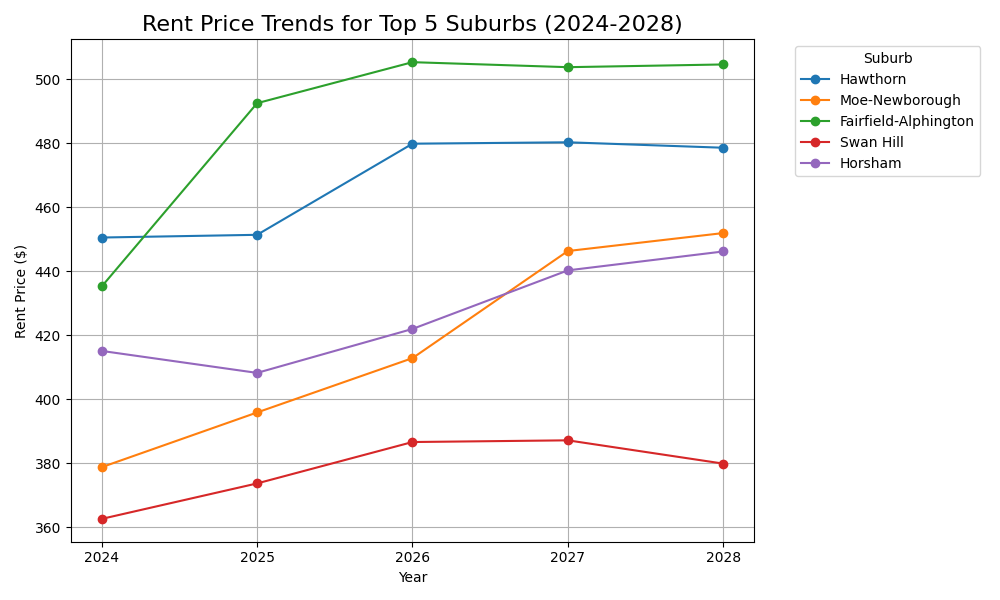

In [13]:
Image(filename="../plots/top5_RF_plot.png")

Both models showed that Hawthorn suburb has the highest predicted growth rate for future 5 years.